# EDA

## Importing the libraries and setting paths
This code imports several useful Python libraries for working with data and images, such as pandas, numpy, and matplotlib, and sets up tools for handling image files and randomness. It also defines the file paths for the training and test datasets, along with CSV files that likely contain labels or metadata, and an Excel file that maps class names to numbers. Overall, it prepares the basic structure needed to load and organize data for a machine learning or image classification project.

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from collections import Counter

TRAIN_DIR = "train"
TEST_DIR = "test"

TRAIN_CSV = "train.csv"
TEST_CSV = "test.csv"
CLASSES_XLSX = "Classes_nummering.xlsx"

## Loading the metadata files

In [3]:
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)
classes_df = pd.read_excel(CLASSES_XLSX)

print(train_df.head())
print(classes_df.head())

                                                  id  label
0  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
1  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
2  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
3  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
4  Black_spiny-tailed_iguana_Black_spiny-tailed_i...      0
   Class                 Unnamed: 1
0      0  Black_spiny_tailed_iguana
1      1                Brown_anole
2      2         Cuban_knight_anole
3      3              Desert_iguana
4      4                Green_anole


## Building a unified dataset index

In [4]:
data = []

for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    
    if not os.path.isdir(class_path):
        continue
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        
        data.append({
            "image_id": img_name,
            "path": img_path,
            "label": class_name,
            "split": "train"
        })

train_index = pd.DataFrame(data)

print(train_index.head())
print(train_index["label"].value_counts())

                                            image_id  \
0  Black_spiny-tailed_iguana_Ctenosaura_similis_2...   
1  Black_spiny-tailed_iguana_Black_spiny-tailed_i...   
2  Black_spiny-tailed_iguana_Black_spiny-tailed_i...   
3  Black_spiny-tailed_iguana_Black_spiny-tailed_i...   
4  Black_spiny-tailed_iguana_Black_spiny-tailed_i...   

                                                path  \
0  train/Black_spiny_tailed_iguana/Black_spiny-ta...   
1  train/Black_spiny_tailed_iguana/Black_spiny-ta...   
2  train/Black_spiny_tailed_iguana/Black_spiny-ta...   
3  train/Black_spiny_tailed_iguana/Black_spiny-ta...   
4  train/Black_spiny_tailed_iguana/Black_spiny-ta...   

                       label  split  
0  Black_spiny_tailed_iguana  train  
1  Black_spiny_tailed_iguana  train  
2  Black_spiny_tailed_iguana  train  
3  Black_spiny_tailed_iguana  train  
4  Black_spiny_tailed_iguana  train  
label
Black_spiny_tailed_iguana    199
Lesser_Antillean_iguana      196
Green_iguana              

## Class distribution

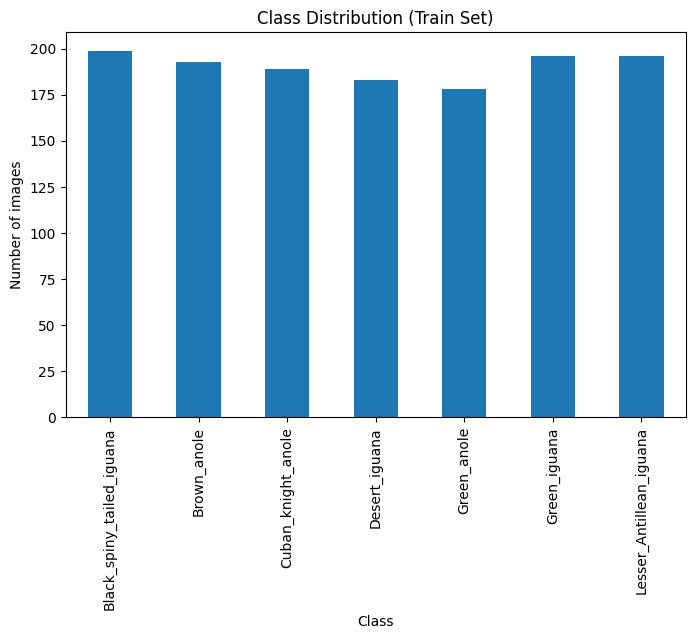

In [5]:
plt.figure(figsize=(8,5))
train_index["label"].value_counts().sort_index().plot(kind="bar")
plt.title("Class Distribution (Train Set)")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.show()

## Visual inspection per class

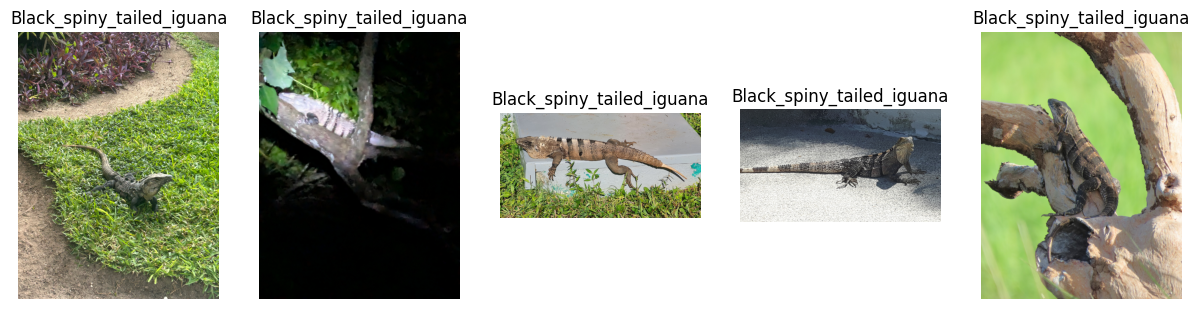

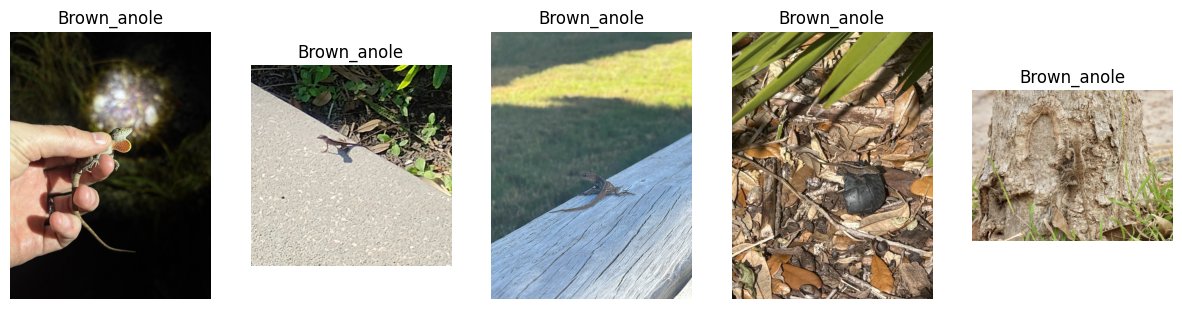

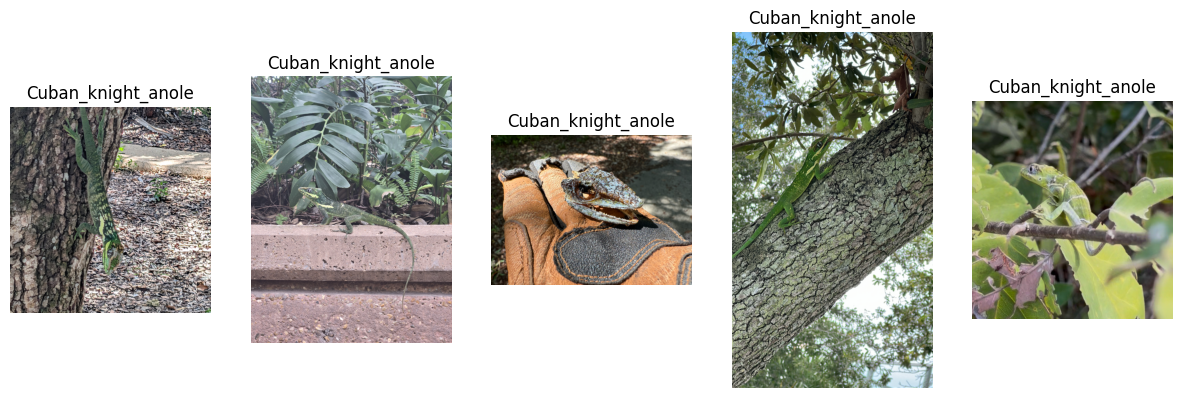

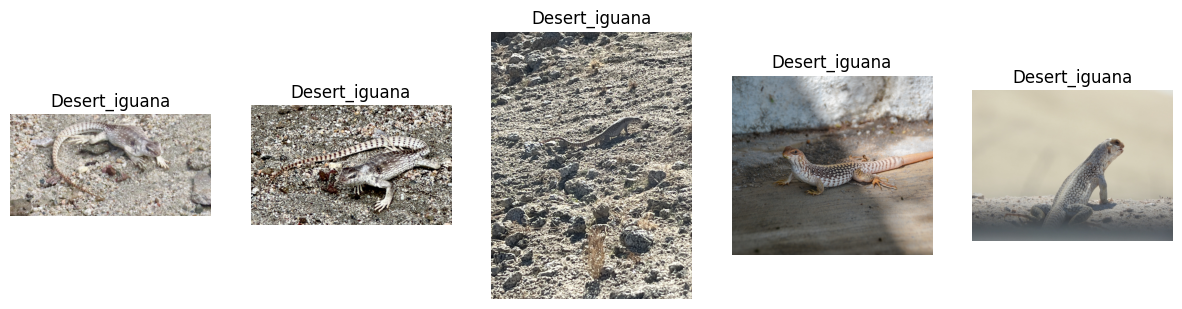

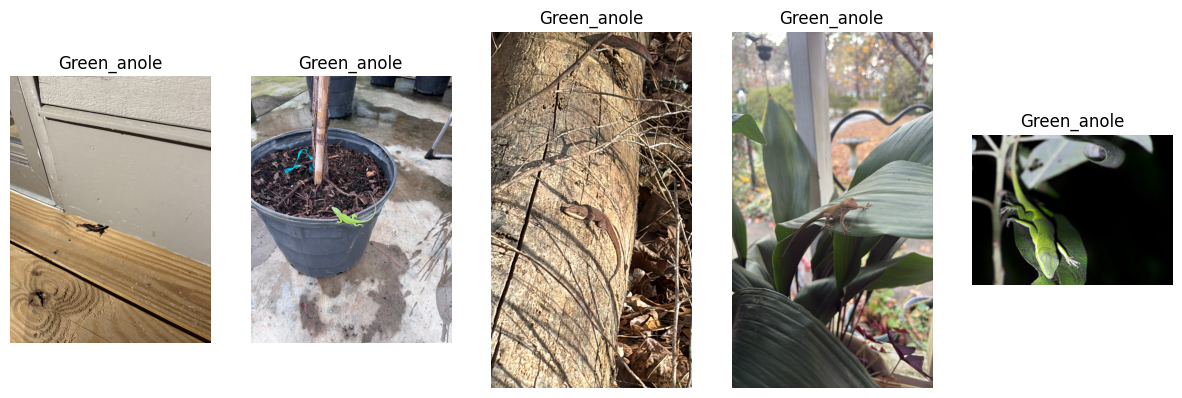

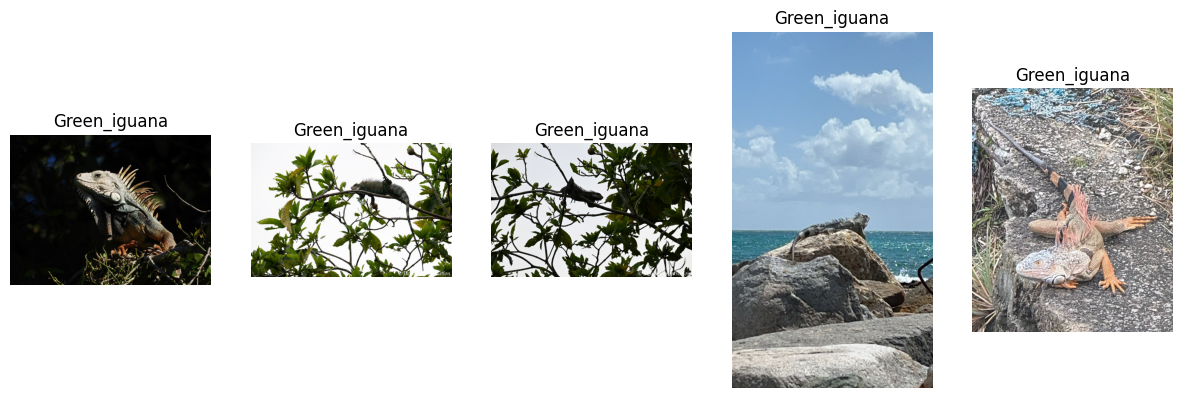

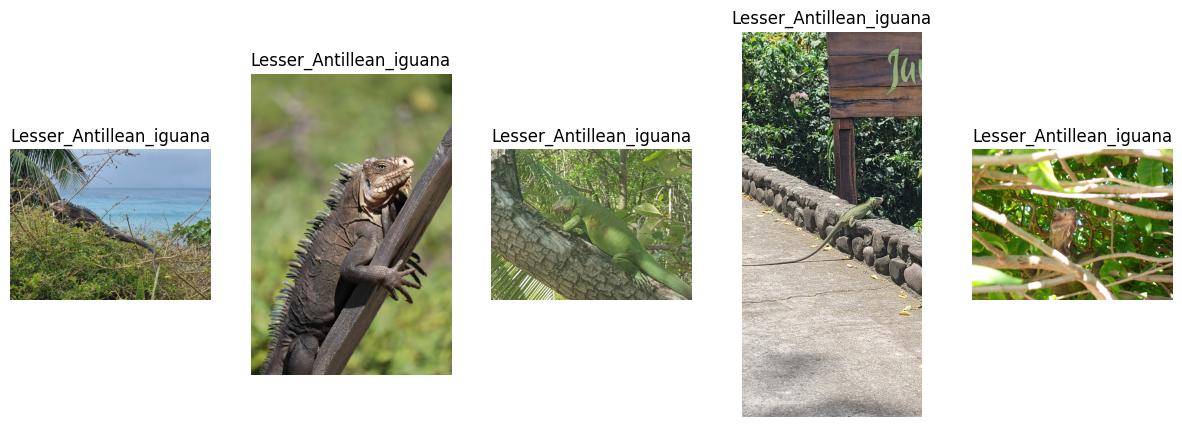

In [6]:
def show_samples(df, class_name, n=5):
    samples = df[df["label"] == class_name].sample(n)
    
    plt.figure(figsize=(15,5))
    
    for i, row in enumerate(samples.itertuples()):
        img = Image.open(row.path)
        
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(class_name)
    
    plt.show()

for cls in sorted(train_index["label"].unique()):
    show_samples(train_index, cls, n=5)

## Image size analysis

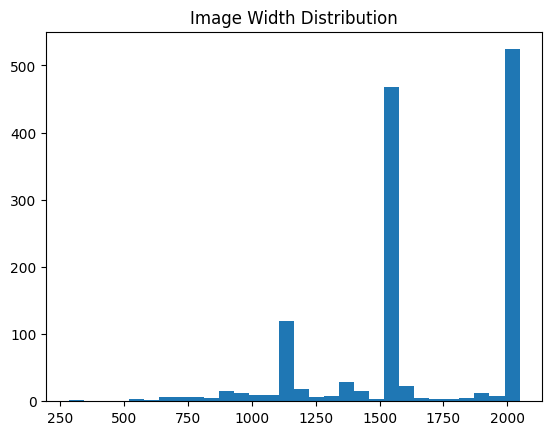

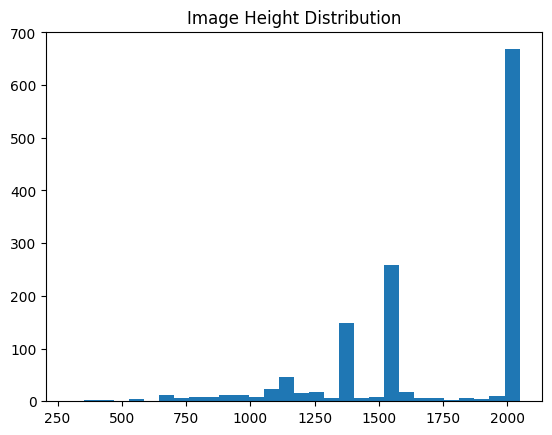

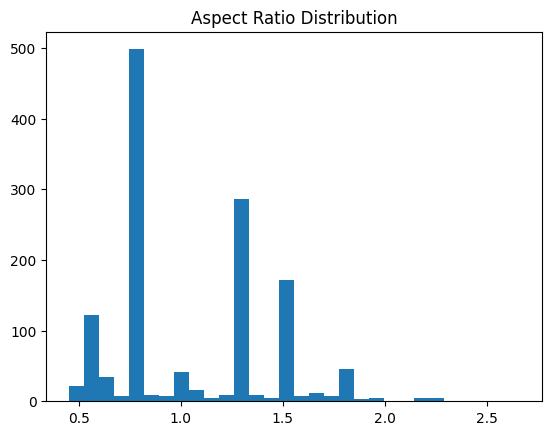

In [7]:
widths = []
heights = []

for path in train_index["path"]:
    with Image.open(path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

train_index["width"] = widths
train_index["height"] = heights
train_index["aspect_ratio"] = train_index["width"] / train_index["height"]

plt.figure()
plt.hist(train_index["width"], bins=30)
plt.title("Image Width Distribution")
plt.show()

plt.figure()
plt.hist(train_index["height"], bins=30)
plt.title("Image Height Distribution")
plt.show()

plt.figure()
plt.hist(train_index["aspect_ratio"], bins=30)
plt.title("Aspect Ratio Distribution")
plt.show()

## Compare visually

Train images: 1334
Test images: 326


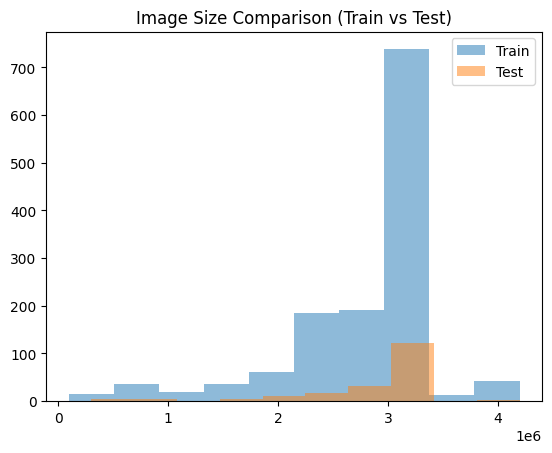

In [8]:
test_files = os.listdir(TEST_DIR)

print("Train images:", len(train_index))
print("Test images:", len(test_files))

test_sizes = []

for img_name in test_files[:200]:  # sample for speed
    path = os.path.join(TEST_DIR, img_name)
    
    with Image.open(path) as img:
        test_sizes.append(img.size)

test_sizes = []

for img_name in test_files[:200]:  # sample for speed
    path = os.path.join(TEST_DIR, img_name)
    
    with Image.open(path) as img:
        test_sizes.append(img.size)

train_sizes = list(zip(train_index["width"], train_index["height"]))

train_areas = [w*h for w, h in train_sizes]
test_areas = [w*h for w, h in test_sizes]

plt.figure()
plt.hist(train_areas, alpha=0.5, label="Train")
plt.hist(test_areas, alpha=0.5, label="Test")
plt.legend()
plt.title("Image Size Comparison (Train vs Test)")
plt.show()

## Corruption check

In [9]:
broken = []

for path in train_index["path"]:
    try:
        img = Image.open(path)
        img.verify()
    except:
        broken.append(path)

print("Broken images:", len(broken))

Broken images: 0


## Class mapping + merge

In [17]:
classes_df.columns = ["Class", "Class_name"]
print(classes_df)

label_map = dict(zip(classes_df["Class"], classes_df["Class_name"]))

   Class                 Class_name
0      0  Black_spiny_tailed_iguana
1      1                Brown_anole
2      2         Cuban_knight_anole
3      3              Desert_iguana
4      4                Green_anole
5      5               Green_iguana
6      6    Lesser_Antillean_iguana


# Generative AI Use